In [10]:
import duckdb
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

con = duckdb.connect('../data/processed/ecommerce.db')
df = con.execute("SELECT * FROM behaviors").df()
df['date'] = pd.to_datetime(df['date'])
print(f"数据量: {len(df):,}")
print(f"日期范围: {df['date'].min()} ~ {df['date'].max()}")
df.head()

数据量: 4,999,325
日期范围: 2017-11-24 00:00:00 ~ 2017-12-03 00:00:00


,user_id,item_id,category_id,behavior_type,timestamp,date,hour
0,1,2268318,2520377,pv,2017-11-24 17:21:10,2017-11-24,17
1,1,2333346,2520771,pv,2017-11-24 22:15:33,2017-11-24,22
2,1,2576651,149192,pv,2017-11-25 01:21:25,2017-11-25,1
3,1,3830808,4181361,pv,2017-11-25 07:04:53,2017-11-25,7
4,1,4365585,2520377,pv,2017-11-25 07:49:06,2017-11-25,7


In [11]:
# 只筛选购买行为
buy_df = df[df['behavior_type'] == 'buy']

# 今天 = 数据最后一天
today = df['date'].max()
print(f"今天（数据最后一天）: {today}")
print(f"购买记录数: {len(buy_df):,}")

# 按用户算 R / F / M
rfm = buy_df.groupby('user_id').agg(
    last_date=('date', 'max'),
    F=('item_id', 'count'),
    M=('item_id', 'nunique')
)
rfm['R'] = (today - rfm['last_date']).dt.days
rfm = rfm.drop(columns=['last_date'])

print(f"\n有购买行为的用户数: {len(rfm):,}")
rfm.head()


今天（数据最后一天）: 2017-12-03 00:00:00
购买记录数: 100,126

有购买行为的用户数: 33,286


,F,M,R
user_id,,,
27,2,2,2
100,8,8,5
117,10,10,5
119,3,3,4
121,1,1,8


In [16]:
r_median = rfm['R'].median()
f_median = rfm['F'].median()
m_median = rfm['M'].median()

rfm['R_score'] = (rfm['R'] <=r_median).astype(int)
rfm['F_score'] = (rfm['F'] >=f_median).astype(int)
rfm['M_score'] = (rfm['M'] >=m_median).astype(int)

print(f"R中位数:{r_median}天, F中位数:{f_median}次, M中位数:{m_median}种")
print(f"\n打分结果分布:")
print(f"R_score=1(最近来过): {(rfm['R_score']==1).sum()} 人")
print(f"F_score=1(高频购买): {(rfm['F_score']==1).sum()} 人")
print(f"M_score=1(品类丰富): {(rfm['M_score']==1).sum()} 人")
rfm.head()

R中位数:2.0天, F中位数:2.0次, M中位数:2.0种

打分结果分布:
R_score=1(最近来过): 18844 人
F_score=1(高频购买): 21892 人
M_score=1(品类丰富): 21485 人


,F,M,R,R_score,F_score,M_score,segment,用户类型
user_id,,,,,,,,
27,2,2,2,1,1,1,111,重要价值用户
100,8,8,5,0,1,1,011,一般价值用户
117,10,10,5,0,1,1,011,一般价值用户
119,3,3,4,0,1,1,011,一般价值用户
121,1,1,8,0,0,0,000,一般挽留用户


In [17]:
rfm['segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

segment_names = {
    '111' :'重要价值用户',
    '110' :'重要发展用户',
    '101' :'重要保持用户',
    '100' :'重要挽留用户',
    '011' :'一般价值用户',
    '010' :'一般发展用户',
    '001' :'一般保持用户',
    '000' :'一般挽留用户',
}
rfm['用户类型'] = rfm['segment'].map(segment_names)

print("各用户类型人数:")
print(rfm['用户类型'].value_counts())
rfm.head()

各用户类型人数:
用户类型
重要价值用户    14234
一般价值用户     7251
一般挽留用户     6999
重要挽留用户     4395
重要发展用户      215
一般发展用户      192
Name: count, dtype: int64


,F,M,R,R_score,F_score,M_score,segment,用户类型
user_id,,,,,,,,
27,2,2,2,1,1,1,111,重要价值用户
100,8,8,5,0,1,1,011,一般价值用户
117,10,10,5,0,1,1,011,一般价值用户
119,3,3,4,0,1,1,011,一般价值用户
121,1,1,8,0,0,0,000,一般挽留用户


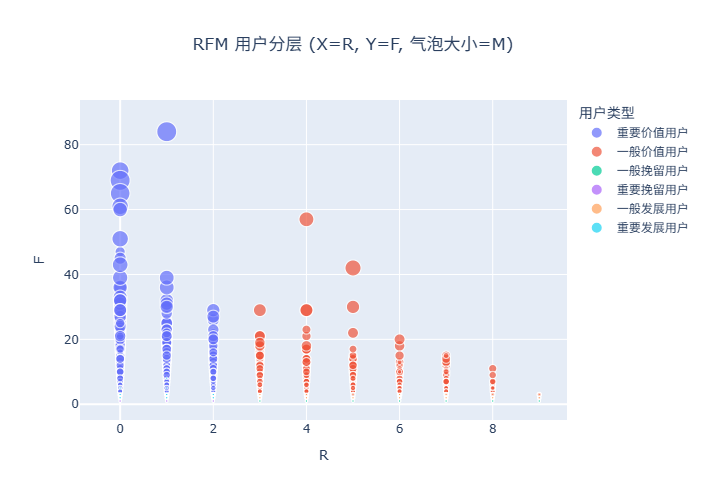

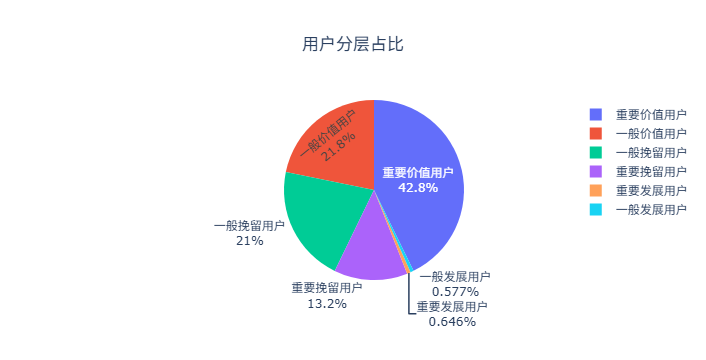

In [18]:
fig1 = px.scatter(rfm, x='R', y='F', size='M', color='用户类型',
                  title='RFM 用户分层 (X=R, Y=F, 气泡大小=M)',
                  hover_data=['M'])
fig1.update_layout(title_x=0.5, height=500)

type_counts = rfm['用户类型'].value_counts().reset_index()
type_counts.columns = ['用户类型', '人数']
fig2 = px.pie(type_counts, values='人数', names='用户类型', title='用户分层占比')
fig2.update_traces(textinfo='percent+label')
fig2.update_layout(title_x=0.5)

fig1.show()
fig2.show()


In [21]:
buy_with_type = buy_df.merge(rfm[['用户类型']], on='user_id', how='inner')

vip = buy_with_type[buy_with_type['用户类型'] =='重要价值用户']
lost = buy_with_type[buy_with_type['用户类型'] =='一般挽留用户']

vip_top = vip['category_id'].value_counts().head(10)
lost_top =lost['category_id'].value_counts().head(10)
print("重要价值用户 - Top10类目:")
print(vip_top)
print("\n一般挽留用户 - Top10类目:")
print(lost_top)

重要价值用户 - Top10类目:
category_id
1464116    1163
2735466    1158
4145813    1043
2885642     954
4756105     903
4801426     849
982926      771
4357323     589
3002561     567
2640118     565
Name: count, dtype: int64

一般挽留用户 - Top10类目:
category_id
2885642    152
4145813    142
4756105    134
2735466    123
1464116    117
4801426     99
4159072     92
982926      91
903809      65
1320293     61
Name: count, dtype: int64
